In [318]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [319]:
def compute_spectra(bins, v, ndft):
    sfdr = np.zeros(len(bins))
    hd3 = np.zeros(len(bins))
    spec_dbv_out = np.zeros((len(bins), ndft//2+1))
    for i in bins:
        y = v[i-1, :]
        y = y[:-1]
        relative_error = (y[-1]-y[-1-ndft])/y[-1]
        print(relative_error)
        y = y[-ndft:]
        spec = np.fft.rfft(y)
        spec_dbv = 20*np.log10(np.abs(spec)/(ndft/2))
        spec_dbv_out[i-1, :] = spec_dbv
        sfdr[i-1] = spec_dbv[i] - np.max(np.delete(spec_dbv, [0, i]))
        hd3[i-1] = spec_dbv[i] - spec_dbv[get_third_harmonic_bin(i, ndft)]
    return sfdr, hd3, spec_dbv_out

In [320]:
def get_third_harmonic_bin(i, ndft):
    """
    Finds the 3rd harmonic bin for a real-valued signal.
    i: fundamental bin index
    nfft: total number of FFT points
    """
    # Step 1: Wrap around the sampling frequency
    wrapped_bin = (3 * i) % ndft
    
    # Step 2: Fold back if it's above Nyquist
    if wrapped_bin > ndft // 2:
        harmonic_bin = ndft - wrapped_bin
    else:
        harmonic_bin = wrapped_bin
        
    return int(harmonic_bin)

In [321]:
df1 = pd.read_csv('./xschem/simulation/tb_boot_bottom_diff.txt', sep='\\s+')
df1

,time,v(vip),v(vop),v(von)
0,1.900000e-09,0.657402,0.632070,0.566974
1,3.900000e-09,0.715501,0.691732,0.508162
2,5.900000e-09,0.768871,0.747291,0.452509
3,7.900000e-09,0.815327,0.796839,0.402909
4,9.900000e-09,0.852968,0.838356,0.361391
...,...,...,...,...
535,6.390000e-08,0.675293,0.895541,0.304223
536,6.590000e-08,0.495713,0.303807,0.895628
537,6.790000e-08,0.732205,0.892709,0.306441
538,6.990000e-08,0.441221,0.312112,0.886807


In [322]:
# Parameters
fs = 500e6
ndft = 31
runs = 15
bins = np.arange(1, runs+1)

In [323]:
vip = np.reshape(df1['v(vip)'].values, [runs, len(df1)//runs])
vop = np.reshape(df1['v(vop)'].values, [runs, len(df1)//runs])
von = np.reshape(df1['v(von)'].values, [runs, len(df1)//runs])
vod = vop - von

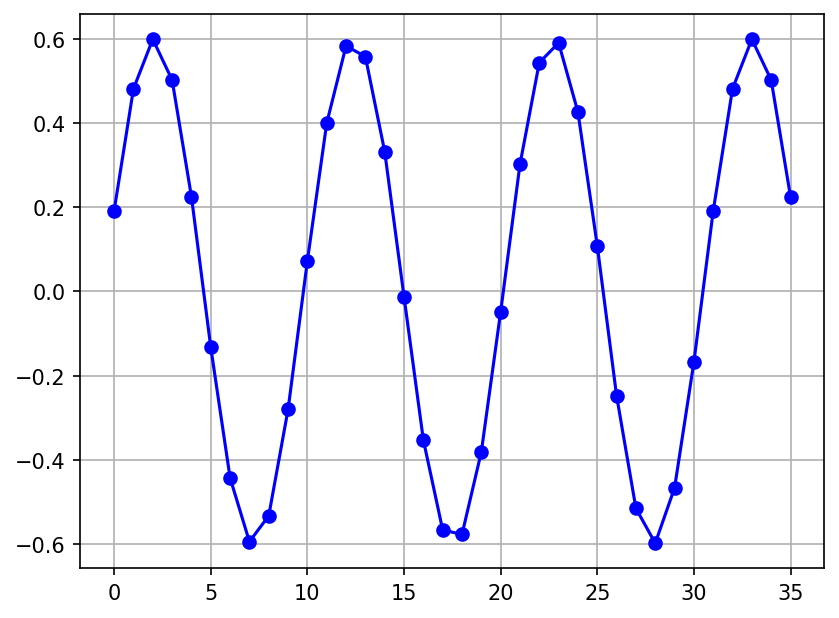

In [324]:
plt.plot(vod[2, :], "b-o")
plt.grid()
plt.show()

In [325]:
hd3_vip = compute_spectra(bins, vip, ndft)[1]
hd3_vop = compute_spectra(bins, vop, ndft)[1]
hd3_vod = compute_spectra(bins, vod, ndft)[1]

1.4227412955137661e-08
5.456394455409827e-08
9.946957382454326e-08
-1.3750491552083808e-09
8.592987155661037e-09
6.639133986046001e-10
4.859555958632223e-10
-3.746433728433993e-07
4.528959341926823e-08
1.2414267335423662e-07
3.230290328276667e-09
-2.745292505505852e-07
5.3049920235059315e-06
5.765562280483373e-06
-3.2020229503188876e-06
4.220285037338234e-06
-2.448298855264872e-07
3.6765365471347084e-07
-7.6001846923662575e-06
3.237136275591856e-05
-5.630957036955277e-06
2.1602038775775228e-08
1.7701729860964657e-06
-2.6466606009029315e-05
4.125213944457512e-06
-2.47445614641076e-08
1.6865289961917753e-05
-5.3035888705033896e-05
-2.151849942847819e-05
1.777951691437141e-05
1.7036520758534366e-05
-7.183938242978003e-07
1.1935714733006705e-06
-6.204089730726116e-05
-0.00011861149477408217
6.811131928800896e-06
-3.1543977959182553e-09
-4.985618814120313e-06
-0.0003594475524312016
1.5031314114225262e-05
-1.0723481042856765e-07
6.448464977801471e-05
-0.0010402789558063795
5.37321138094716e-

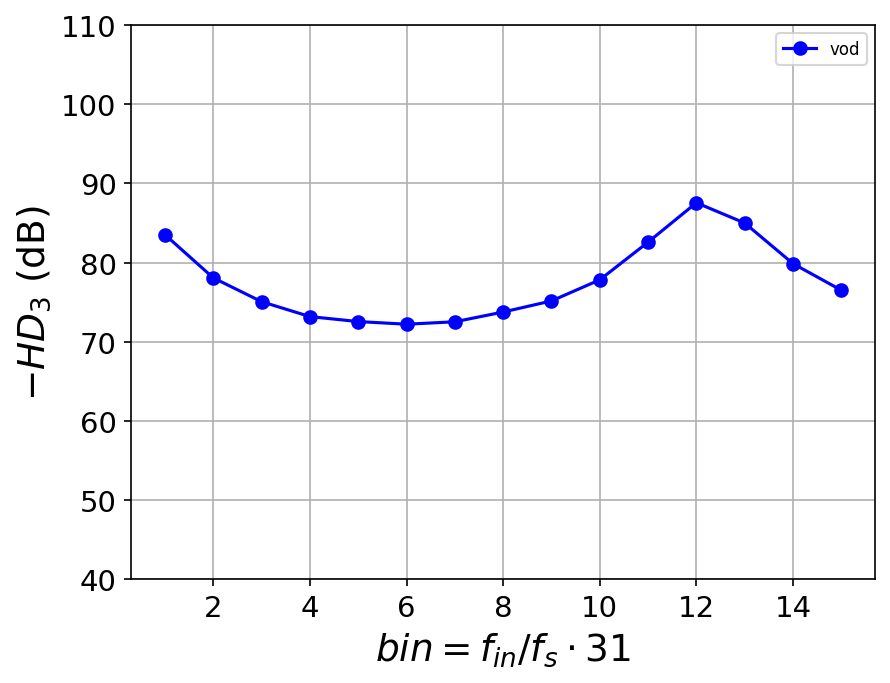

In [326]:
plt.rcParams['figure.dpi'] = 150
#plt.plot(bins, hd3_vip, "r--", label='vi')
#plt.plot(bins, hd3_vop, "g-o", label='vop')
plt.plot(bins, hd3_vod, "b-o", label='vod')
    
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("$-HD_3$ (dB)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(40, 110)
plt.grid(True)
plt.legend(fontsize=8)
plt.show()

1.7036520758534366e-05
-7.183938242978003e-07
1.1935714733006705e-06
-6.204089730726116e-05
-0.00011861149477408217
6.811131928800896e-06
-3.1543977959182553e-09
-4.985618814120313e-06
-0.0003594475524312016
1.5031314114225262e-05
-1.0723481042856765e-07
6.448464977801471e-05
-0.0010402789558063795
5.37321138094716e-05
-1.927178018239676e-05


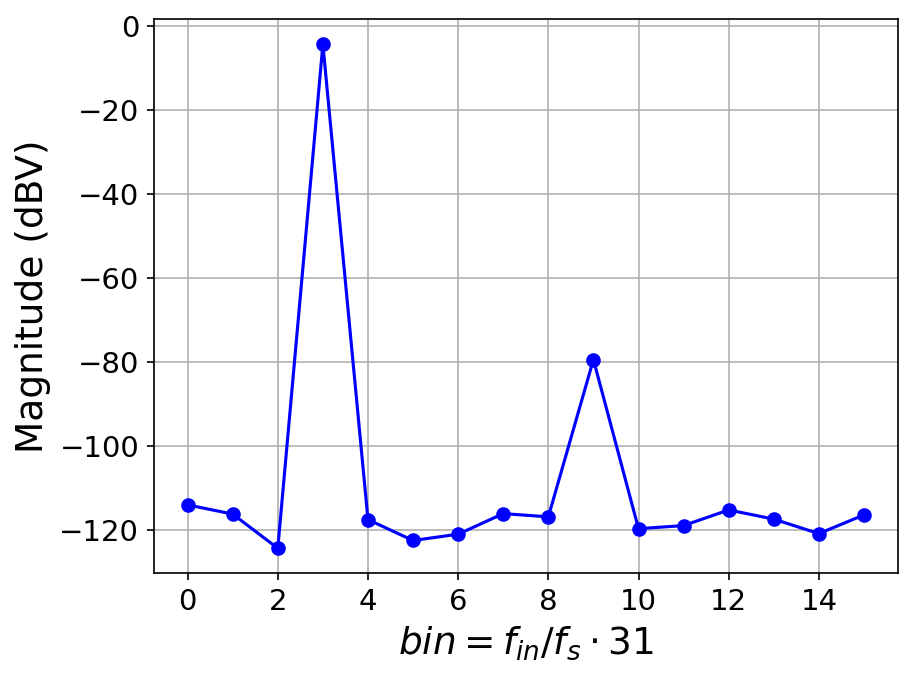

In [327]:
spec_dbv_out = compute_spectra(bins, vod, ndft)[2]

plt.plot(spec_dbv_out[2, :], "b-o")
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("Magnitude (dBV)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.ylim(25, 72)
plt.grid(True)
plt.show()
